# Raster data preparations

In this exercise, the raster data for the classification excercises is prepared. For machine learning tasks, the input raster data must follow these rules.

1) Data and labels images must have the same:
* Coordinate system
* Resolution / pixel size
* Data origin (min x and y), so that one pixel in both files covers exactly the same area.

*Note, in CNN exercise we use `Torchgeo` package, that could do this aligning itself on-the-fly.*

2) Labels image must be a raster image of type Integer and 1 band. The class numbers start from 0 and grow to `number_of_classes - 1`. So for binary classification the labels image has values 0 and 1. For 4 class multiclass labels, values 0 to 3. If needed, vector labels need to be rasterized.

3) Data image must be of type Float with values between 0 and 1 (sometimes -1 to 1), may have several bands, usually has.

Here we prepare labels for all data image area, for pixel-wise machine learning, data could be prepared also for specific points/pixels only. See for example: [SYKE land use classification with LUCAS points](https://geohpc.readthedocs.io/en/latest/lessons/L3/03_LandCoverClassification_syke_Parallelization.html)

## Data sources

#### Labels:
Data sources: 
* Finnish Food Authority, [Agricultural parcels](https://www.paikkatietohakemisto.fi/geonetwork/srv/eng/catalog.search#/metadata/e4467d0b-51f9-41f2-bd7e-8ff48a2cb083). Data downloaded from [GeoPortti GeoCubes](https://vm0160.kaj.pouta.csc.fi/geocubes/). Agricultural parcels are originally vector data, but have been rasterized to GeoCubes.
* LUKE, [MVMI forest inventory, site main class](http://urn.fi/urn:nbn:fi:fd-849cabd2-0ae5-3455-b6f3-a39086cce33c). Data downloaded from [Paituli](https://paituli.csc.fi/).
* SYKE, [CORINE](https://www.paikkatietohakemisto.fi/geonetwork/srv/eng/catalog.search#/metadata/%7B0B4B2FAC-ADF1-43A1-A829-70F02BF0C0E5%7D). Data downloaded from [GeoPortti GeoCubes](https://vm0160.kaj.pouta.csc.fi/geocubes/).


#### Data image:
* FMI, [10-days Sentinel2 mosaic](https://ckan.ymparisto.fi/dataset/sentinel-2-satellite-image-mosaics-s2gm-sentinel-2-satelliittikuvamosaiikki-s2gm), original images from ESA.

The advantage of useing GeoCubes is that there all data is pre-processed so that it fits the requirements mentioned above. 

All datasets used for this exercise have already same coordinate system (20m). The `stackstac` package takes care of harmonizing data origin and resolution (20m).

For finding the files [Paituli STAC](https://paituli.csc.fi/stac.html) is used. For longer intro to STAC and its usege see [CSC STAC examples](https://github.com/csc-training/geocomputing/tree/master/python/STAC).

## Data processing results

The goal of this exercise is to have 8 raster files:
* 4 labels files and 4 data files with different extents
* Extents: deep learning training, shallow learnging training, validation, test.
* All files:
    * Coordinate system: Finnish ETRS-TM35FIN, EPSG:3067
    * Resolution: 20m

#### Labels

Multiclass classification raster: 
* 1 - forest from forest inventory data
* 2 - fields from agricultural parcels data
* 3 - water from CORINE land cover data
* 0 - everything else 

#### Data image

* Sentinel2 mosaic, we include data from 2 different dates (May and July), to have more data values. Final dataset has 8 bands based on bands: 2, 3, 4 and 8 on dates: 2021-05-11 and 2021-07-21, reflection values scaled to [0 ... 1]. The bands source data is: 
     *  'b02' / '2021-05-11'
     *  'b02' / '2021-07-21'
     *  'b03' / '2021-05-11'
     *  'b03' / '2021-07-21'
     *  'b04' / '2021-05-11'
     *  'b04' / '2021-07-21'
     *  'b08' / '2021-05-11'
     *  'b08' / '2021-07-21'

## Data processing main steps
* Set STAC specs, file names and bbox extents for different files
* Connect to STAC catalog and define function to fetch data via STAC

#### Labels

1) Fetch original datasets via Paituli STAC and explore them.
2) Create a new labels dataset and calculate class values based on the original datasets
3) Save data to 4 files with different extents.

#### Data image

1) Fetch Sentinel-2 11-day mosaics via Paituli STAC, including only required bands
3) Normalize the data values, the reflectance values are originally between 0 and 1, but for storage they have been multiplied with 10 000, so here the normalization is simple division with 10 000.
4) Stack data from different dates just as bands.
3) Save data to 4 files with different extents.

This workbook requires at least 6Gb memory. 1 core is enough, but xarray could use more, if working with bigger datasets.

## Imports and paths

In [1]:
import os
import numpy as np

# Handling raster data
import rioxarray
import xarray

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd

# STAC search and data fetching
import pyproj
import pystac_client
import stackstac

# Bbox creation for plotting the extents
import geopandas as gpd
from shapely.geometry import Polygon

Set STAC specs for all datasets: collcetion_id, time-period and names of assets.

Use [STAC browser](https://radiantearth.github.io/stac-browser/#/external/paituli.csc.fi/geoserver/ogc/stac/v1?.language=en) to find suitable datasets and their specs: 
* The collection ID is available behind I-source button.
* Asset names, select a random item and see the left pane.
* Available time, see Temporal Extent in STAC browser, use STAC search or look from GeoCubes or Paituli services, which years are available.

In [2]:
# Paituli STAC
stac_endpoint = "https://paituli.csc.fi/geoserver/ogc/stac/v1"

# Fields 
fields_stac_id = "land_parcels_at_geocubes"
fields_time = "2016-07-01"
fields_assets = ["20m"]

# CORINE
corine_stac_id = "corine_land_cover_at_geocubes"
corine_time = "2018-07-01"
corine_assets = ["20m"]

# Forest
forest_stac_id = "luke_vmi_paatyyppi_at_paituli" 
forest_time = "2023-07-01"
forest_assets = ["luke_vmi_paatyyppi_at_paituli_tiff"]

# Sentinel-2 11-day mosaic
sentinel2_stac_id = "sentinel_2_11_days_mosaics_at_fmi"
sentinel2_time1 = "2021-05-11"
sentinel2_time2 = "2021-07-21"
sentinel2_assets = ['b02', 'b03', 'b04', 'b08']

Set folder and file names.

In [3]:
# Folders
base_folder = os.path.join(os.sep, 'scratch', 'project_462001167', 'students', os.environ.get('USER'), 'GeoML')
exercise_folder = os.path.join(base_folder, '02_raster_data_preparation') 
data_folder = os.path.join(base_folder,'data', 'raster')

data_shallow = os.path.join(data_folder, 'data_shallow.tif')
data_deep = os.path.join(data_folder, 'data_deep.tif')
data_test = os.path.join(data_folder, 'data_test.tif')
data_validation = os.path.join(data_folder, 'data_validation.tif')

labels_shallow = os.path.join(data_folder, 'labels_shallow.tif')
labels_deep = os.path.join(data_folder, 'labels_deep.tif')
labels_test = os.path.join(data_folder, 'labels_test.tif')
labels_validation = os.path.join(data_folder, 'labels_validation.tif')
data_test

'/scratch/project_462001167/students/tegelkat/GeoML/data/raster/data_test.tif'

In [4]:
#TODO, remove fix
os.chdir(exercise_folder)

Create new folder for prepared data, if it does not exist yet.

In [5]:
if not os.path.isdir(data_folder):
    os.makedirs(data_folder)

### Set extent for different files

Define extents for training, validation and test data. The data is from Southern Finland.

In [6]:
x_min_3067 = 250000
y_min_3067 = 6690000
x_max_3067 = x_min_3067 + 200000 
y_max_3067 = y_min_3067 + 60000
bbox_3067 = (x_min_3067, y_min_3067, x_max_3067, y_max_3067)

x_min_3067_test = x_min_3067
x_max_3067_test = x_min_3067_test + 10000
x_min_3067_deep = x_max_3067_test
x_max_3067_deep = x_max_3067 - 10000
x_min_3067_shallow = 350000 
x_max_3067_shallow = x_min_3067_shallow + 60000
x_min_3067_validation = x_max_3067 - 10000
x_max_3067_validation = x_max_3067

data_epsg = 3067
data_epsg_string = "EPSG:" + str(data_epsg)

Plot the different extents.

In [7]:
x_point_list_shallow = [x_min_3067_shallow, x_min_3067_shallow, x_max_3067_shallow, x_max_3067_shallow, x_min_3067_shallow]
x_point_list_deep = [x_min_3067_deep, x_min_3067_deep, x_max_3067_deep, x_max_3067_deep, x_min_3067_deep]
x_point_list_validation = [x_min_3067_validation, x_min_3067_validation, x_max_3067_validation, x_max_3067_validation, x_min_3067_validation]
x_point_list_test = [x_min_3067_test, x_min_3067_test, x_max_3067_test, x_max_3067_test, x_min_3067_test]
y_point_list = [y_min_3067, y_max_3067, y_max_3067, y_min_3067, y_min_3067]

polygon_shallow = Polygon(zip(x_point_list_shallow, y_point_list))
polygon_deep = Polygon(zip(x_point_list_deep, y_point_list))
polygon_test = Polygon(zip(x_point_list_test, y_point_list))
polygon_validation = Polygon(zip(x_point_list_validation, y_point_list))

#polygons = [polygon_test, polygon_shallow, polygon_deep]
d = {'label': ['deep', 'shallow', 'test', 'validation'], 'geometry': [polygon_deep, polygon_shallow, polygon_test, polygon_validation]}
polygons = gpd.GeoDataFrame(d, crs=data_epsg_string)  
polygons.explore(column='label')

## STAC set-up

Open STAC end-point, the queries are done to here.

In [8]:
catalog = pystac_client.Client.open(stac_endpoint)

Function to convert bbox to WGS-84 coordinate system, required by STAC search

In [9]:
def bbox_to_wgs(bbox, epsg_code):
    x_min, y_min, x_max, y_max = bbox    
    epsg_string = "EPSG:" + str(epsg_code)
    long_min, lat_min = pyproj.Proj(epsg_string)(x_min, y_min, inverse=True)
    long_max, lat_max  = pyproj.Proj(epsg_string)(x_max, y_max, inverse=True)
    bbox_wgs = [long_min, lat_min, long_max, lat_max]
    return bbox_wgs

Function to query STAC catalog with given collection ID, time period and bbox. Fetch the data of found items, for given assets. Resolution (20m) is fixed here, but could be different from original data.

In [10]:
def fetch_stac_layer_with_bbox(collection_id, assets, time_period, bbox, epsg):

    bbox_wgs = bbox_to_wgs(bbox, epsg)
    #data_epsg_string = "EPSG:" + str(epsg)
    
    search = catalog.search(
        bbox=bbox_wgs,
        collections=[collection_id],
        datetime=time_period,
    )
    
    cube = stackstac.stack(
        items=search.item_collection(),
        bounds=bbox_3067, 
        assets=assets,
        resolution=20,
        xy_coords='center', 
        epsg=epsg
    ).squeeze()
    if "time" in cube.dims:
        cube = cube.max(dim='time') # Here we use only data with one timestamp, but geocubes data is split to mapsheets, so this joins the mapsheets to same timestamp.
    cube.compute()
    return cube
    

## Labels processing

Fetch data via STAC.

In [11]:
forest = fetch_stac_layer_with_bbox(forest_stac_id, forest_assets, forest_time, bbox_3067, data_epsg)
forest

<xarray.DataArray 'stackstac-97864d625ef3bbbe7c0937709f67010f' (y: 3000,
                                                                x: 10000)> Size: 240MB
dask.array<getitem, shape=(3000, 10000), dtype=float64, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/13)
    time            datetime64[ns] 8B 2023-01-01
    id              <U44 176B 'luke_vmi_paatyyppi_at_paituli_paatyyppi_2023'
    band            <U34 136B 'luke_vmi_paatyyppi_at_paituli_tiff'
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    ...              ...
    start_datetime  <U29 116B '2023-01-01T00:00:00.000+00:00'
    proj:transform  object 8B {0.0, 7778304.0, 57632.0, 1.0, 16.0, -16.0}
    end_datetime    <U29 116B '2023-12-31T00:00:00.000+00:00'
    proj:shape      object 8B {73472, 42240}
    title           <U34 136B 'luke_vmi_paatyyppi_at_paituli_tiff'
    epsg            int64 8B 3067
Attributes:
    spec:        RasterSpec(epsg=3067, bounds=(250000, 6690000, 450000, 67500...
    crs:         epsg:3067
    transform:   | 20.00, 0.00, 250000.00|\n| 0.00,-20.00, 6750000.00|\n| 0.0...
    resolution:  20

/LUMI_TYKKY_NLzHrIC/miniconda/envs/env1/lib/python3.11/site-packages/dask/array/reductions.py:655: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [12]:
fields = fetch_stac_layer_with_bbox(fields_stac_id, fields_assets, fields_time, bbox_3067, data_epsg)
fields

<xarray.DataArray 'stackstac-1f9d559602291579f81135e47390e3b5' (y: 3000,
                                                                x: 10000)> Size: 240MB
dask.array<_nanmax_skip-aggregate, shape=(3000, 10000), dtype=float64, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates:
    band            <U3 12B '20m'
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    gsd             int64 8B 20
    start_datetime  <U29 116B '2016-01-01T00:00:00.000+00:00'
    end_datetime    <U29 116B '2016-12-31T00:00:00.000+00:00'
    proj:shape      object 8B {5000}
    title           <U3 12B '20m'
    epsg            int64 8B 3067

In [13]:
corine = fetch_stac_layer_with_bbox(corine_stac_id, corine_assets, corine_time, bbox_3067, data_epsg)
corine

<xarray.DataArray 'stackstac-5177efba1bf849d966226e3826517a47' (y: 3000,
                                                                x: 10000)> Size: 240MB
dask.array<_nanmax_skip-aggregate, shape=(3000, 10000), dtype=float64, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates:
    band            <U3 12B '20m'
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    gsd             int64 8B 20
    start_datetime  <U29 116B '2018-01-01T00:00:00.000+00:00'
    end_datetime    <U29 116B '2018-12-31T00:00:00.000+00:00'
    proj:shape      object 8B {5000}
    title           <U3 12B '20m'
    epsg            int64 8B 3067

### Explore original labels data

Plot small part of the data image.

Text(0.5, 1.0, 'Forest main type')

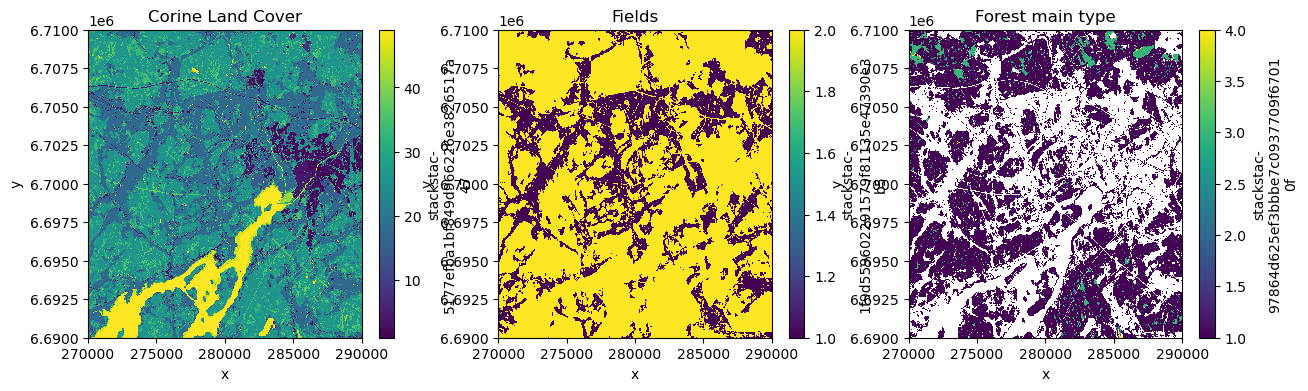

In [14]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(15, 4))
corine.isel(x=slice(1000,2000), y=slice(2000,3000)).plot(ax=ax[0])
ax[0].set_title("Corine Land Cover")
fields.isel(x=slice(1000,2000), y=slice(2000,3000)).plot(ax=ax[1])
ax[1].set_title("Fields")
forest.isel(x=slice(1000,2000), y=slice(2000,3000)).plot(ax=ax[2])
ax[2].set_title("Forest main type")

### Reclassify

Create a new dataset with classification assigned based on the 3 original rasters.

In [15]:
labels = fields.copy()
#labels = labels.where(labels != 2, other=0)
labels = xarray.where(labels == 2, 0, labels) # Not-field to 0
labels = xarray.where(labels == 1, 2, labels) # Fields to class 2
labels = xarray.where(forest < 50, 1, labels) # Forest to class 1
labels = xarray.where(corine == 47, 3, labels) # Rivers, to class 3
labels = xarray.where(corine == 48, 3, labels) # Lakes, to class 3
labels = xarray.where(corine == 49, 3, labels) # Sea, to class 3

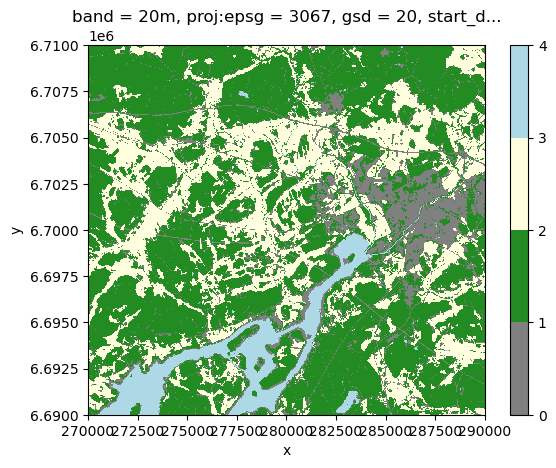

In [16]:
classes = [0, 1, 2, 3]
colors  = ["gray", "forestgreen", "lightyellow", "lightblue"]
cmap = ListedColormap(colors)
class_bounds = np.array(classes + [classes[-1] + 1])   # e.g., [11,12,21,22,23,31,32]
norm = BoundaryNorm(class_bounds, len(colors))
labels.isel(x=slice(1000,2000), y=slice(2000,3000)).plot(cmap=cmap, norm=norm)

See number of pixels in each class.

In [17]:
def get_class_stats(data):
    stats = np.unique(data, return_counts=True)
    df = pd.DataFrame({
        "value": stats[0],
        "count": stats[1]
    })
    return df

In [18]:
labels_stats = get_class_stats(labels)
print("Labels classes:")
labels_stats

Labels classes:


,value,count
0,0.0,2933809
1,1.0,17417424
2,2.0,8336100
3,3.0,1312667


### Save labels files

Add coordinate system info, as `rioxarray` wants it.

In [19]:
labels.rio.write_crs(data_epsg, inplace=True)

<xarray.DataArray (y: 3000, x: 10000)> Size: 240MB
dask.array<where, shape=(3000, 10000), dtype=float64, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/14)
    band            <U3 12B '20m'
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    gsd             int64 8B 20
    start_datetime  <U29 116B '2018-01-01T00:00:00.000+00:00'
    ...              ...
    title           <U3 12B '20m'
    epsg            int64 8B 3067
    time            datetime64[ns] 8B 2023-01-01
    id              <U44 176B 'luke_vmi_paatyyppi_at_paituli_paatyyppi_2023'
    proj:transform  object 8B {0.0, 7778304.0, 57632.0, 1.0, 16.0, -16.0}
    spatial_ref     int64 8B 0

Save the file with 4 different extents for deep and shallow model training, validation and testing.

In [20]:
def save_bbox_to_geotiff(data, minx, miny, maxx, maxy, filename):
    clipped = data.rio.clip_box(minx, miny, maxx, maxy)
    clipped.rio.to_raster(filename, tiled=True)

In [21]:
# Deep learning, model training
save_bbox_to_geotiff(labels, x_min_3067_deep, y_min_3067, x_max_3067_deep, y_max_3067, labels_deep)
# Shallow learning, model training
save_bbox_to_geotiff(labels, x_min_3067_shallow, y_min_3067, x_max_3067_shallow, y_max_3067, labels_shallow)
# Validation
save_bbox_to_geotiff(labels, x_min_3067_validation, y_min_3067, x_max_3067_validation, y_max_3067, labels_validation)
# Test
save_bbox_to_geotiff(labels, x_min_3067_test, y_min_3067, x_max_3067_test, y_max_3067, labels_test)

## Data image processing

1. Find data using Paituli STAC catalogue, separately for 2 dates.

In [22]:
sentinel2_1 = fetch_stac_layer_with_bbox(sentinel2_stac_id, sentinel2_assets, sentinel2_time1, bbox_3067, data_epsg)
sentinel2_1

<xarray.DataArray 'stackstac-b24a508a395804d16c45f01ac4b26527' (band: 4,
                                                                y: 3000,
                                                                x: 10000)> Size: 960MB
dask.array<getitem, shape=(4, 3000, 10000), dtype=float64, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
    time            datetime64[ns] 8B 2021-05-11
    id              <U53 212B 'Sentinel-2_global_mosaic_dekadi_2021-05-11_202...
  * band            (band) <U3 48B 'b02' 'b03' 'b04' 'b08'
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    gsd             float64 8B 20.0
    start_datetime  <U29 116B '2021-05-11T00:00:00.000+00:00'
    proj:transform  object 8B {0, 1, 7799840, -20, 20, 50200}
    end_datetime    <U29 116B '2021-05-20T23:59:59.000+00:00'
    title           (band) <U3 48B 'b02' 'b03' 'b04' 'b08'
    epsg            int64 8B 3067
Attributes:
    spec:        RasterSpec(epsg=3067, bounds=(250000, 6690000, 450000, 67500...
    crs:         epsg:3067
    transform:   | 20.00, 0.00, 250000.00|\n| 0.00,-20.00, 6750000.00|\n| 0.0...
    resolution:  20

In [23]:
sentinel2_2 = fetch_stac_layer_with_bbox(sentinel2_stac_id, sentinel2_assets, sentinel2_time2, bbox_3067, data_epsg)
sentinel2_2

<xarray.DataArray 'stackstac-6c553875cc780306550d180d53e2a53b' (band: 4,
                                                                y: 3000,
                                                                x: 10000)> Size: 960MB
dask.array<getitem, shape=(4, 3000, 10000), dtype=float64, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
    time            datetime64[ns] 8B 2021-07-21
    id              <U53 212B 'Sentinel-2_global_mosaic_dekadi_2021-07-21_202...
  * band            (band) <U3 48B 'b02' 'b03' 'b04' 'b08'
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    gsd             float64 8B 20.0
    start_datetime  <U29 116B '2021-07-21T00:00:00.000+00:00'
    proj:transform  object 8B {0, 1, 7799840, -20, 20, 50200}
    end_datetime    <U29 116B '2021-07-31T23:59:59.000+00:00'
    title           (band) <U3 48B 'b02' 'b03' 'b04' 'b08'
    epsg            int64 8B 3067
Attributes:
    spec:        RasterSpec(epsg=3067, bounds=(250000, 6690000, 450000, 67500...
    crs:         epsg:3067
    transform:   | 20.00, 0.00, 250000.00|\n| 0.00,-20.00, 6750000.00|\n| 0.0...
    resolution:  20

Join data from both dates to one Xarray DataArray.

In [24]:
sentinel2 = xarray.concat([sentinel2_1, sentinel2_2], dim="time")
sentinel2

<xarray.DataArray 'stackstac-b24a508a395804d16c45f01ac4b26527' (time: 2,
                                                                band: 4,
                                                                y: 3000,
                                                                x: 10000)> Size: 2GB
dask.array<concatenate, shape=(2, 4, 3000, 10000), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * time            (time) datetime64[ns] 16B 2021-05-11 2021-07-21
    id              (time) <U53 424B 'Sentinel-2_global_mosaic_dekadi_2021-05...
  * band            (band) <U3 48B 'b02' 'b03' 'b04' 'b08'
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    gsd             float64 8B 20.0
    start_datetime  (time) <U29 232B '2021-05-11T00:00:00.000+00:00' '2021-07...
    proj:transform  object 8B {0, 1, 7799840, -20, 20, 50200}
    end_datetime    (time) <U29 232B '2021-05-20T23:59:59.000+00:00' '2021-07...
    title           (band) <U3 48B 'b02' 'b03' 'b04' 'b08'
    epsg            int64 8B 3067
Attributes:
    spec:        RasterSpec(epsg=3067, bounds=(250000, 6690000, 450000, 67500...
    crs:         epsg:3067
    transform:   | 20.00, 0.00, 250000.00|\n| 0.00,-20.00, 6750000.00|\n| 0.0...
    resolution:  20

Normalize the data values, the reflectance values are originally between 0 and 1, but for storage Sentinel-2 data has been multiplied with 10 000, so here the normalization is simple division with 10 000. For other data sources, this step is likely different.

In [25]:
sentinel2 = sentinel2 / 10000.0

Plot small part of both scens as RGB images.

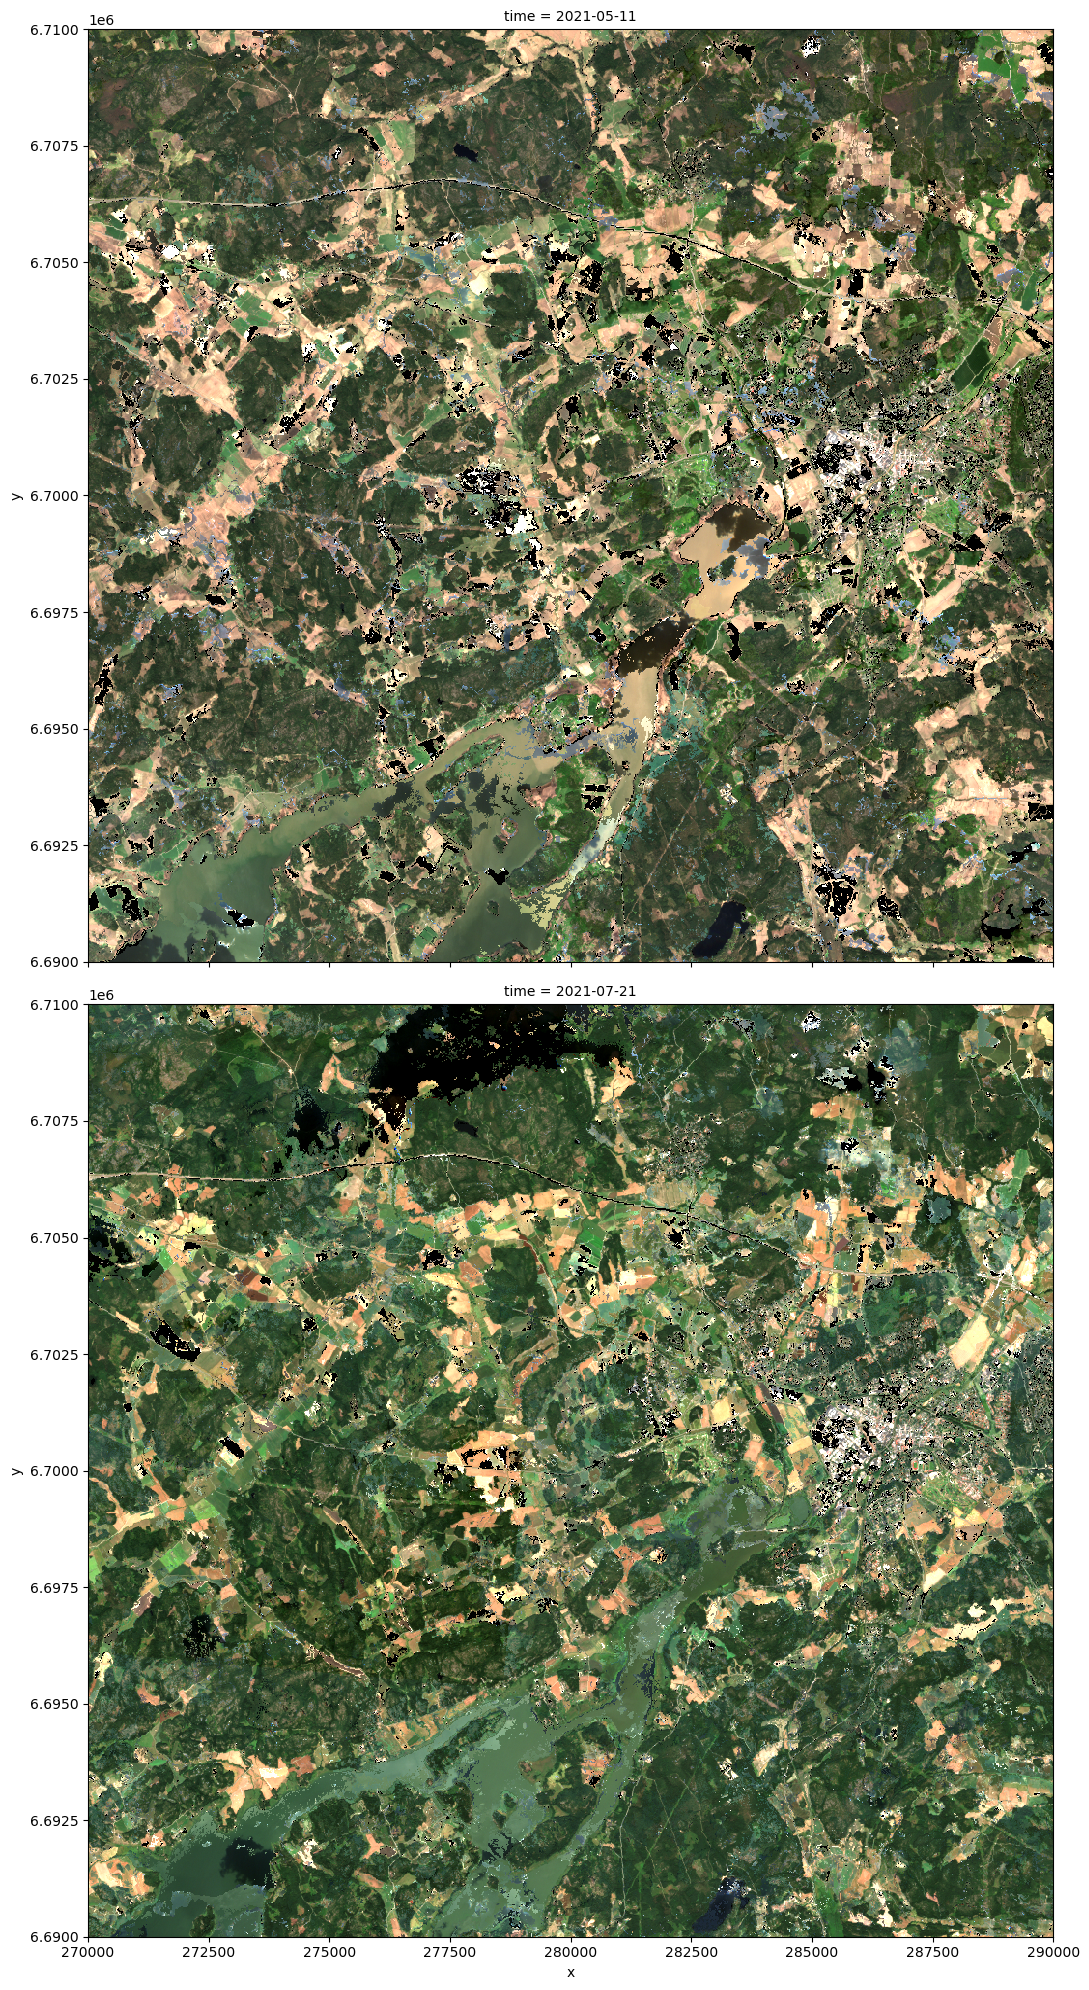

In [26]:
cube_2021_rgb = sentinel2.isel(x=slice(1000,2000), y=slice(2000,3000)).sel(band=['b04', 'b03', 'b02'])
cube_2021_rgb.plot.imshow(row="time", rgb="band", robust=True, size=10)

Stack different data from different dates just as bands for saving it to a file.

In [27]:
stacked = sentinel2.stack(z=("band", "time"))
stacked

<xarray.DataArray 'stackstac-b24a508a395804d16c45f01ac4b26527' (y: 3000,
                                                                x: 10000, z: 8)> Size: 2GB
dask.array<reshape, shape=(3000, 10000, 8), dtype=float64, chunksize=(1024, 1024, 1), chunktype=numpy.ndarray>
Coordinates: (12/13)
    id              (z) <U53 2kB 'Sentinel-2_global_mosaic_dekadi_2021-05-11_...
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    gsd             float64 8B 20.0
    start_datetime  (z) <U29 928B '2021-05-11T00:00:00.000+00:00' ... '2021-0...
    ...              ...
    end_datetime    (z) <U29 928B '2021-05-20T23:59:59.000+00:00' ... '2021-0...
    title           (z) <U3 96B 'b02' 'b02' 'b03' 'b03' 'b04' 'b04' 'b08' 'b08'
    epsg            int64 8B 3067
  * z               (z) object 64B MultiIndex
  * band            (z) <U3 96B 'b02' 'b02' 'b03' 'b03' 'b04' 'b04' 'b08' 'b08'
  * time            (z) datetime64[ns] 64B 2021-05-11 2021-07-21 ... 2021-07-21

Change the axis order for rasterio and add coordinate system info as rasterio wants to have it.

In [28]:
final = stacked.transpose('z', 'y', 'x')
final.rio.write_crs("epsg:3067", inplace=True)
final

<xarray.DataArray 'stackstac-b24a508a395804d16c45f01ac4b26527' (z: 8, y: 3000,
                                                                x: 10000)> Size: 2GB
dask.array<transpose, shape=(8, 3000, 10000), dtype=float64, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/14)
    id              (z) <U53 2kB 'Sentinel-2_global_mosaic_dekadi_2021-05-11_...
  * x               (x) float64 80kB 2.5e+05 2.5e+05 2.5e+05 ... 4.5e+05 4.5e+05
  * y               (y) float64 24kB 6.75e+06 6.75e+06 ... 6.69e+06 6.69e+06
    proj:epsg       int64 8B 3067
    gsd             float64 8B 20.0
    start_datetime  (z) <U29 928B '2021-05-11T00:00:00.000+00:00' ... '2021-0...
    ...              ...
    title           (z) <U3 96B 'b02' 'b02' 'b03' 'b03' 'b04' 'b04' 'b08' 'b08'
    epsg            int64 8B 3067
  * z               (z) object 64B MultiIndex
  * band            (z) <U3 96B 'b02' 'b02' 'b03' 'b03' 'b04' 'b04' 'b08' 'b08'
  * time            (z) datetime64[ns] 64B 2021-05-11 2021-07-21 ... 2021-07-21
    spatial_ref     int64 8B 0

Save image data to a file.

In [29]:
# Deep learning, model training
save_bbox_to_geotiff(final, x_min_3067_deep, y_min_3067, x_max_3067_deep, y_max_3067, data_deep)
# Shallow learning, model training
save_bbox_to_geotiff(final, x_min_3067_shallow, y_min_3067, x_max_3067_shallow, y_max_3067, data_shallow)
# Validation
save_bbox_to_geotiff(final, x_min_3067_validation, y_min_3067, x_max_3067_validation, y_max_3067, data_validation)
# Test
save_bbox_to_geotiff(final, x_min_3067_test, y_min_3067, x_max_3067_test, y_max_3067, data_test)

Double-check that all is fine. Pay attention to coordinate system, pixel size and data origin.

In [30]:
!gdalinfo {data_test}

Driver: GTiff/GeoTIFF
Files: /scratch/project_462001167/students/tegelkat/GeoML/data/raster/data_test.tif
Size is 500, 3000
Coordinate System is:
PROJCRS["ETRS89 / TM35FIN(E,N)",
    BASEGEOGCRS["ETRS89",
        ENSEMBLE["European Terrestrial Reference System 1989 ensemble",
            MEMBER["European Terrestrial Reference Frame 1989"],
            MEMBER["European Terrestrial Reference Frame 1990"],
            MEMBER["European Terrestrial Reference Frame 1991"],
            MEMBER["European Terrestrial Reference Frame 1992"],
            MEMBER["European Terrestrial Reference Frame 1993"],
            MEMBER["European Terrestrial Reference Frame 1994"],
            MEMBER["European Terrestrial Reference Frame 1996"],
            MEMBER["European Terrestrial Reference Frame 1997"],
            MEMBER["European Terrestrial Reference Frame 2000"],
            MEMBER["European Terrestrial Reference Frame 2005"],
            MEMBER["European Terrestrial Reference Frame 2014"],
        

In [31]:
!gdalinfo {labels_test} 

Driver: GTiff/GeoTIFF
Files: /scratch/project_462001167/students/tegelkat/GeoML/data/raster/labels_test.tif
Size is 500, 3000
Coordinate System is:
PROJCRS["ETRS89 / TM35FIN(E,N)",
    BASEGEOGCRS["ETRS89",
        ENSEMBLE["European Terrestrial Reference System 1989 ensemble",
            MEMBER["European Terrestrial Reference Frame 1989"],
            MEMBER["European Terrestrial Reference Frame 1990"],
            MEMBER["European Terrestrial Reference Frame 1991"],
            MEMBER["European Terrestrial Reference Frame 1992"],
            MEMBER["European Terrestrial Reference Frame 1993"],
            MEMBER["European Terrestrial Reference Frame 1994"],
            MEMBER["European Terrestrial Reference Frame 1996"],
            MEMBER["European Terrestrial Reference Frame 1997"],
            MEMBER["European Terrestrial Reference Frame 2000"],
            MEMBER["European Terrestrial Reference Frame 2005"],
            MEMBER["European Terrestrial Reference Frame 2014"],
      

The data preparations for classification exercises are now ready, check `../data/raster` folder, that you have 8 .tif files there. Therea are also 8 .tif.aux.xml, which GDAL creates automatically with some metadata of the raster files.